# Omar — Data Preparation for Transformer & LoRA
**BESSTIE: Sentiment & Sarcasm Classification across English Varieties**
University of Surrey · Semester 2, 2026

**Prerequisites:** Run Yusrah's `NLP_EDA.ipynb` first to generate `clean_text` and TF-IDF artefacts.

This notebook covers:
1. Vocabulary analysis (Section 1.2) — Jaccard similarity, TF-IDF cosine similarity, heatmaps
2. Linguistic feature analysis — punctuation, CAPS, emoji, sentence length
3. Variety-specific term extraction — Australian, Indian, British
4. Error analysis prep — tricky cases per variety
5. RoBERTa tokenization
6. LoRA subset creation + tokenization (Gemma / Phi-2)

## 0. Setup

In [1]:
import sys
from pathlib import Path


root = Path.cwd()
while not (root / 'src').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.data_loader import get_BESSTIE_splits
from src.vocabulary_analysis import VocabularyAnalysis
from src.linguistic_analysis import LinguisticFeatureAnalysis
from src.transformer_tokenization import tokenize_roberta, tokenize_lora_subset
from src.lr_feature_extraction import tfidf_features

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('✅ Imports OK')

c:\Users\hp\NLP-sequence-classification\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK


In [ ]:

df_all, df_train, df_val, df_test = get_BESSTIE_splits()
for df in [df_all, df_train, df_val, df_test]:
    df['Sarcasm'] = df['Sarcasm'].astype(int)
    df['Sentiment'] = df['Sentiment'].astype(float)

print(f'Total rows: {len(df_all):,}')
print(f'Columns: {list(df_all.columns)}')

Total rows: 6,243
Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm', 'split']


## 1. Vocabulary Analysis (Section 1.2 Requirement)

VOCABULARY ANALYSIS
Vocabulary sizes:
  en-AU: 16,617 unique words
  en-IN: 13,776 unique words
  en-UK: 14,991 unique words

Jaccard similarity matrix:
        en-AU   en-IN   en-UK
en-AU  1.0000  0.2242  0.2684
en-IN  0.2242  1.0000  0.2364
en-UK  0.2684  0.2364  1.0000

Pairwise Jaccard scores:
  en-AU ↔ en-IN: 0.2242  (shared words: 5,567)
  en-AU ↔ en-UK: 0.2684  (shared words: 6,688)
  en-IN ↔ en-UK: 0.2364  (shared words: 5,501)

TF-IDF cosine similarity matrix:
        en-AU   en-IN   en-UK
en-AU  1.0000  0.7483  0.8871
en-IN  0.7483  1.0000  0.8027
en-UK  0.8871  0.8027  1.0000

Pairwise cosine scores:
  en-AU ↔ en-IN: 0.7483
  en-AU ↔ en-UK: 0.8871
  en-IN ↔ en-UK: 0.8027

✅ Heatmap saved to: ./reports\figures\vocabulary_similarity_heatmap.png


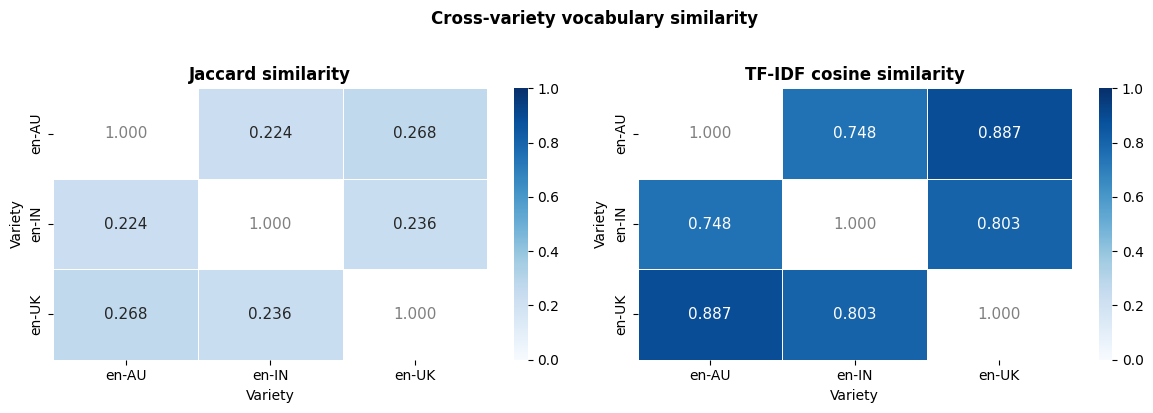

In [ ]:
vocab_analyser = VocabularyAnalysis(
    df_all=df_all,
    text_col='text',          
    variety_col='variety',
    save_path='./reports'
)

df_jaccard, df_cosine, vocab_per_variety = vocab_analyser.run(save=True)

In [ ]:
pairs = [('en-AU', 'en-IN'), ('en-AU', 'en-UK'), ('en-IN', 'en-UK')]
print('Pairwise similarity summary:')
print(f'  {"Pair":<20} {"Jaccard":>10} {"TF-IDF Cosine":>15}')
print('  ' + '-'*47)
for a, b in pairs:
    j = df_jaccard.loc[a, b]
    c = df_cosine.loc[a, b]
    print(f'  {a} ↔ {b:<10} {j:>10.4f} {c:>15.4f}')

Pairwise similarity summary:
  Pair                    Jaccard   TF-IDF Cosine
  -----------------------------------------------
  en-AU ↔ en-IN          0.2242          0.7483
  en-AU ↔ en-UK          0.2684          0.8871
  en-IN ↔ en-UK          0.2364          0.8027


## 2. Linguistic Feature Analysis


Sarcastic vs Non-sarcastic — linguistic features:
              Feature  Non-sarcastic (mean)  Sarcastic (mean)  Δ (%)
Exclamation marks (!)                 0.215             0.108  -50.0
   Question marks (?)                 0.109             0.285  161.4
       Ellipsis (...)                 0.106             0.089  -15.5
       ALL CAPS words                 0.257             0.352   36.6
          Emoji count                 0.000             0.000    0.0
  Avg sentence length                13.577            13.516   -0.4

✅ Figure saved to: ./reports\figures\linguistic_features_sarcasm.png


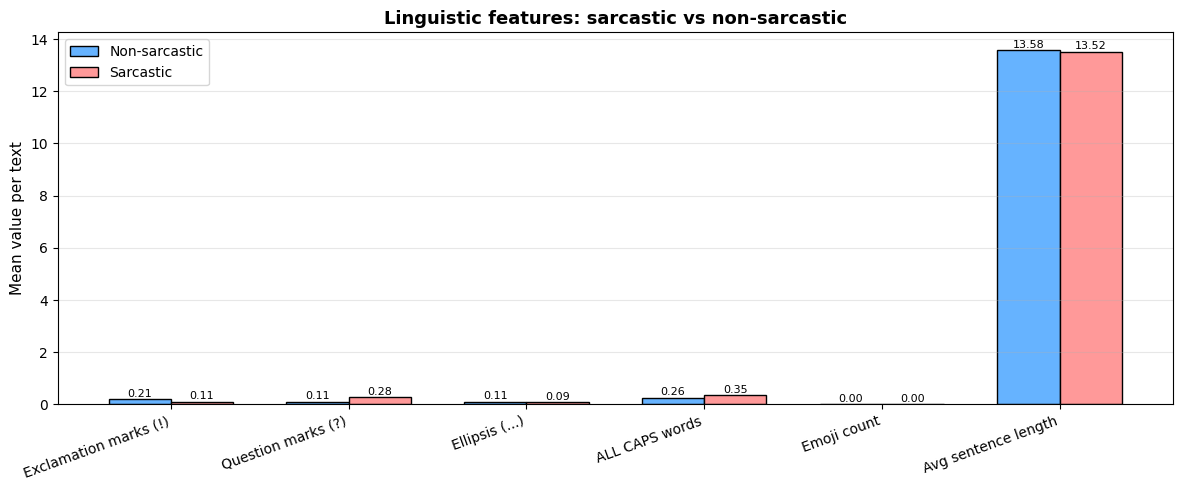

              Feature  Non-sarcastic (mean)  Sarcastic (mean)  Δ (%)
Exclamation marks (!)                 0.215             0.108  -50.0
   Question marks (?)                 0.109             0.285  161.4
       Ellipsis (...)                 0.106             0.089  -15.5
       ALL CAPS words                 0.257             0.352   36.6
          Emoji count                 0.000             0.000    0.0
  Avg sentence length                13.577            13.516   -0.4


In [ ]:
ling_analyser = LinguisticFeatureAnalysis(
    df_all=df_all,
    text_col='text',
    sarcasm_col='Sarcasm',
    variety_col='variety',
    save_path='./reports'
)

df_ling_compare = ling_analyser.compare_sarcasm_features(save=True)
print(df_ling_compare.to_string(index=False))

## 3. Variety-Specific Term Extraction

In [ ]:
variety_terms = ling_analyser.extract_variety_terms(top_n=30, save=True)

for variety, df_terms in variety_terms.items():
    print(f'\nTop 10 distinctive terms for {variety}:')
    print(df_terms[['term', 'count_in_variety', 'distinctiveness_ratio']].head(10).to_string(index=False))


VARIETY-SPECIFIC TERM EXTRACTION

Top 30 distinctive terms for en-AU:
           term  count_in_variety  distinctiveness_ratio  is_seed_term
         threat                 4                   2.87         False
           uluu                 3                   2.87         False
       necklace                 6                   2.87         False
    bricklayers                 3                   2.87         False
  cabinetmakers                 3                   2.87         False
       shifting                 4                   2.87         False
           fmia                 3                   2.87         False
    occupations                 8                   2.87         False
          teals                 3                   2.87         False
       graphite                10                   2.87         False
       driveway                 3                   2.87         False
       flashing                 5                   2.87         False
      

## 4. Error Analysis Prep

In [ ]:
df_tricky = ling_analyser.identify_tricky_cases(n_per_variety=10, save=True)

print(f'\nTotal tricky cases identified: {len(df_tricky)}')
print(df_tricky.groupby(['variety', 'reason']).size())


ERROR ANALYSIS PREP — tricky cases

en-AU (10 cases):
  [sarcastic+positive] Some universities accept the STAT exam in lieu of year 12. You pay to take it and the benefit is that it takes 4 hours r...
  [sarcastic+positive] Ghosts need to wash their clothes, too
(I'm not sure, maybe some kind of macrame art that's being protected by the bags?...
  [sarcastic+positive] Went here for dinner Thursday 11th April. Food was nice and decent portion sizes and staff were friendly enough. Only do...
  [sarcastic+positive] The cheapest toilet paper is a bidet. Then you'll only use two squares to pat yourself dry and it won't matter where you...
  [sarcastic+positive] Yes, I always do. I think my body just decides it needs more fat. Then I always lose it over summer....
  [high-punct+non-sarcastic] Had a lovely lunch here with the kids on Wednesday, friendly staff and delicious food! We had the lunch banquet, delicio...
  [high-punct+non-sarcastic] Everything but the store is wonderful. Staff, fo

## 5. Feature Extraction — RoBERTa Tokenization

> **Note:** Loads `clean_text` from Yusrah's pipeline. If `clean_text` column is not present, falls back to `text`.

In [ ]:
TEXT_COL = 'clean_text' if 'clean_text' in df_train.columns else 'text'
print(f'Using text column: "{TEXT_COL}"')

roberta_datasets = tokenize_roberta(
    df_train=df_train,
    df_val=df_val,
    df_test=df_test,
    text_col=TEXT_COL,
    label_cols=['Sentiment', 'Sarcasm'],
    max_length=128,
    save_path='./tokenized/roberta'
)

print('\nRoBERTa dataset features:', roberta_datasets['train'].features)

Using text column: "text"

Loading tokenizer: roberta-base
Tokenizing with max_length=128...


Saving the dataset (1/1 shards): 100%|██████████| 2183/2183 [00:00<00:00, 188619.69 examples/s]

✅ RoBERTa tokenized dataset saved to: ./tokenized/roberta
   Train: 3,747  Val: 313  Test: 2,183

RoBERTa dataset features: {'text': Value('large_string'), 'sentiment': Value('float64'), 'sarcasm': Value('int64'), 'variety': Value('large_string'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [9]:
df_train['variety'] = df_train['Sentiment'].astype(str) + "_" + df_train['Sarcasm'].astype(str)
df_val['variety']   = df_val['Sentiment'].astype(str) + "_" + df_val['Sarcasm'].astype(str)
df_test['variety']  = df_test['Sentiment'].astype(str) + "_" + df_test['Sarcasm'].astype(str)

print(df_train.columns)

Index(['text', 'variety', 'source', 'Sentiment', 'Sarcasm', 'split'], dtype='str')


## 6. Feature Extraction — LoRA Subset Tokenization


In [ ]:
X_train, X_val, X_test, vectorizer = tfidf_features(
    df_train=df_train,
    df_validation=df_val,
    df_test=df_test,
    text_column=TEXT_COL,
    max_features=15000,
    save_path="./models/tfidf"
)

y_train = df_train[['Sentiment', 'Sarcasm']]
y_val   = df_val[['Sentiment', 'Sarcasm']]
y_test  = df_test[['Sentiment', 'Sarcasm']]


## Summary of outputs

| Artefact | Location |
|---|---|
| Vocabulary similarity heatmap | `reports/figures/vocabulary_similarity_heatmap.png` |
| Linguistic features chart | `reports/figures/linguistic_features_sarcasm.png` |
| Variety-specific term CSVs | `reports/variety_terms_en_AU.csv` etc. |
| Tricky cases CSV | `reports/tricky_cases_error_analysis.csv` |
| RoBERTa tokenized dataset | `tokenized/roberta/` |
| LoRA tokenized subsets | `tokenized/lora/google_gemma-2b/` |